# Part 1: 

In [1]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import src.dataloader as dl

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
OUT_DIR = Path("res/part1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Data Visualisation

# v-Prediction Flow Matching at `D = 2`

### Helper Functions

In [3]:
def scatter_plot(data1, data2,
                 title1="Dataset 1", title2="Dataset 2",
                 suptitle=None, save_path=None, show=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, data, title in [(axes[0], data1, title1), (axes[1], data2, title2)]:
        ax.scatter(data[:, 0], data[:, 1], alpha=0.5, s=10)
        ax.set_title(title)
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"saved -> {save_path}")
    if show:
        plt.show()
    plt.close(fig)

saved -> res/part1/swiss_roll_visual.png


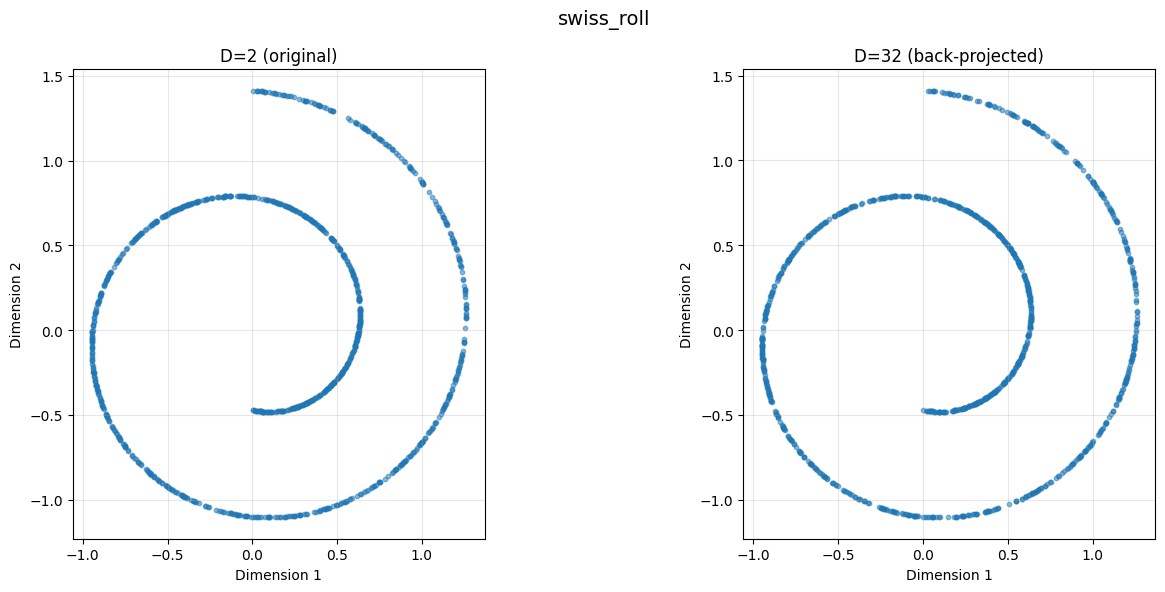

saved -> res/part1/gaussians_visual.png


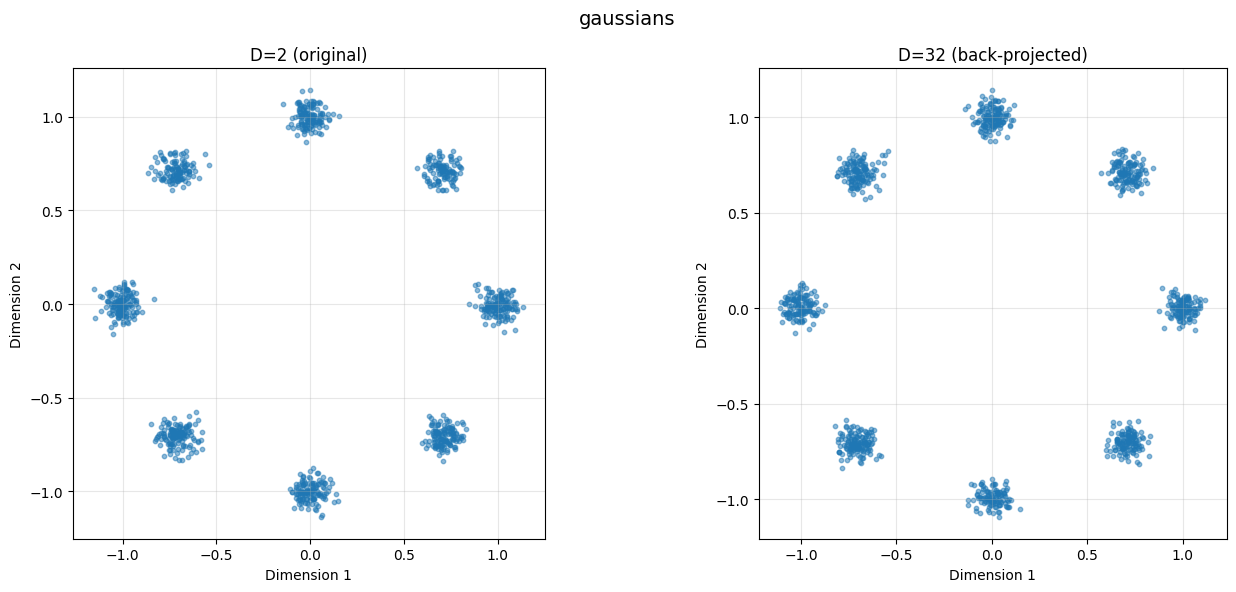

saved -> res/part1/circles_visual.png


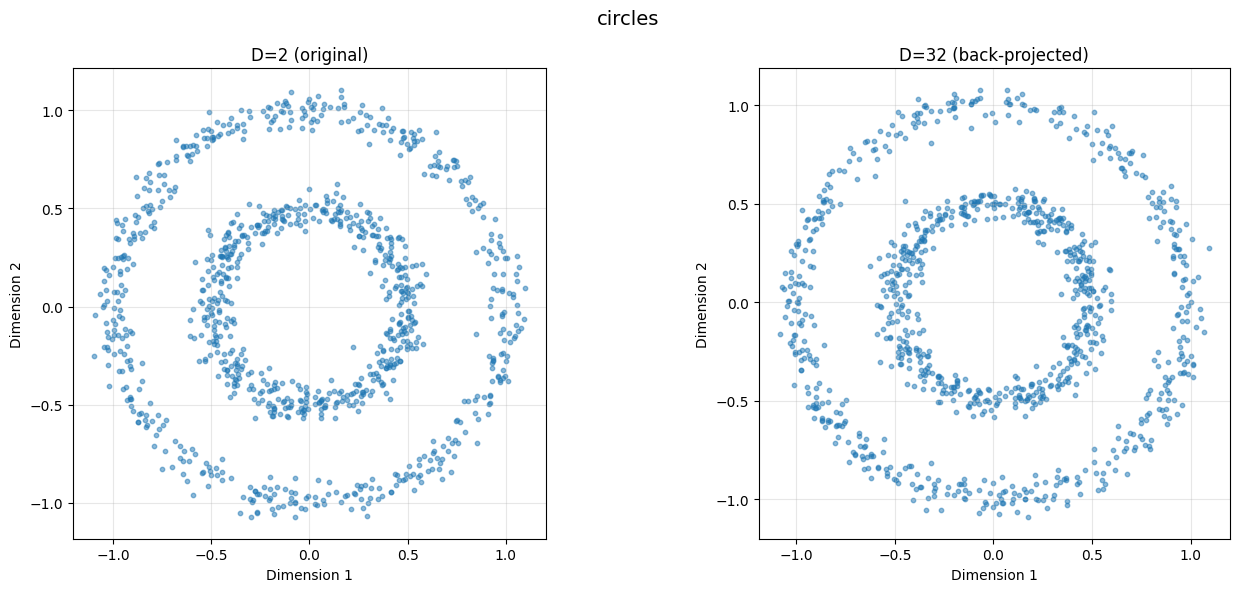

In [4]:
sz = [2, 32]
for dataset in dl.AVAILABLE_DATASETS:
    image_low = next(iter(dl.get_dataloader(name=dataset, dim=sz[0])))
    image_high = next(iter(dl.get_dataloader(name=dataset, dim=sz[1])))
    image_high_2d = dl.ToyDiffusionDataset(dataset, dim=sz[1]).to_2d(image_high)

    scatter_plot(
        image_low, image_high_2d,
        title1=f"D={sz[0]} (original)",
        title2=f"D={sz[1]} (back-projected)",
        suptitle=f"{dataset}",
        save_path=OUT_DIR / f"{dataset}_visual.png",
    )

### Helper Functions

In [5]:
N_GEN = 2048

In [6]:
def scatter_plot(generated, truth, title=None,
                 save_path=None, show=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].scatter(truth[:, 0], truth[:, 1],
                    alpha=0.6, s=10, c="orange")
    axes[0].set_title("Ground Truth")
    axes[0].set_xlabel("Dimension 1")
    axes[0].set_ylabel("Dimension 2")
    axes[0].set_aspect("equal")

    axes[1].scatter(generated[:, 0], generated[:, 1],
                    alpha=0.6, s=10, c="C0")
    axes[1].set_title("Generated")
    axes[1].set_xlabel("Dimension 1")
    axes[1].set_ylabel("Dimension 2")
    axes[1].set_aspect("equal")

    if title:
        fig.suptitle(title, fontsize=14)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"saved -> {save_path}")
    if show:
        plt.show()
    plt.close(fig)

In [7]:
device = torch.device('cpu')

In [8]:
results = {}

for dataset in dl.AVAILABLE_DATASETS:

    # Dataloader
    dataloader = get_dataloader(name=dataset, dim=2, batch_size=1024)
    # MLP Model
    model = JiM(hidden_dim=256, D=2)
    model = model.to(device)
    # Optimiser
    opt = optim.Adam(model.parameters(), lr=1e-3)
    # Train Steps
    train_steps = 25000
    # Denoising steps
    steps = 50

    # Train
    loss = train_n_steps(model, dataloader, opt, device, train_steps, 'v', 'v',)

    # Generate
    denoiser = Denoiser(model, steps=steps, D=2)
    out = denoiser.generate(N_GEN, 'v', device)
    truth = next(iter(dataloader))[:N_GEN].cpu().numpy()

    results[dataset] = {
        "generated": out.cpu().numpy(),
        "truth": truth,
        "loss": loss,
    }

step    500/25000  loss 1.088929
step   1000/25000  loss 1.007171
step   1500/25000  loss 0.984644
step   2000/25000  loss 0.967726
step   2500/25000  loss 0.964989
step   3000/25000  loss 0.962435
step   3500/25000  loss 0.957432
step   4000/25000  loss 0.954901
step   4500/25000  loss 0.952781
step   5000/25000  loss 0.955558
step   5500/25000  loss 0.952055
step   6000/25000  loss 0.954558
step   6500/25000  loss 0.950430
step   7000/25000  loss 0.952987
step   7500/25000  loss 0.949667
step   8000/25000  loss 0.951603
step   8500/25000  loss 0.950607
step   9000/25000  loss 0.950671
step   9500/25000  loss 0.949343
step  10000/25000  loss 0.950136
step  10500/25000  loss 0.947769
step  11000/25000  loss 0.950137
step  11500/25000  loss 0.948416
step  12000/25000  loss 0.948705
step  12500/25000  loss 0.949790
step  13000/25000  loss 0.945485
step  13500/25000  loss 0.944009
step  14000/25000  loss 0.946806
step  14500/25000  loss 0.946553
step  15000/25000  loss 0.946552
step  1550

saved -> res/part1/JiM_grid.png


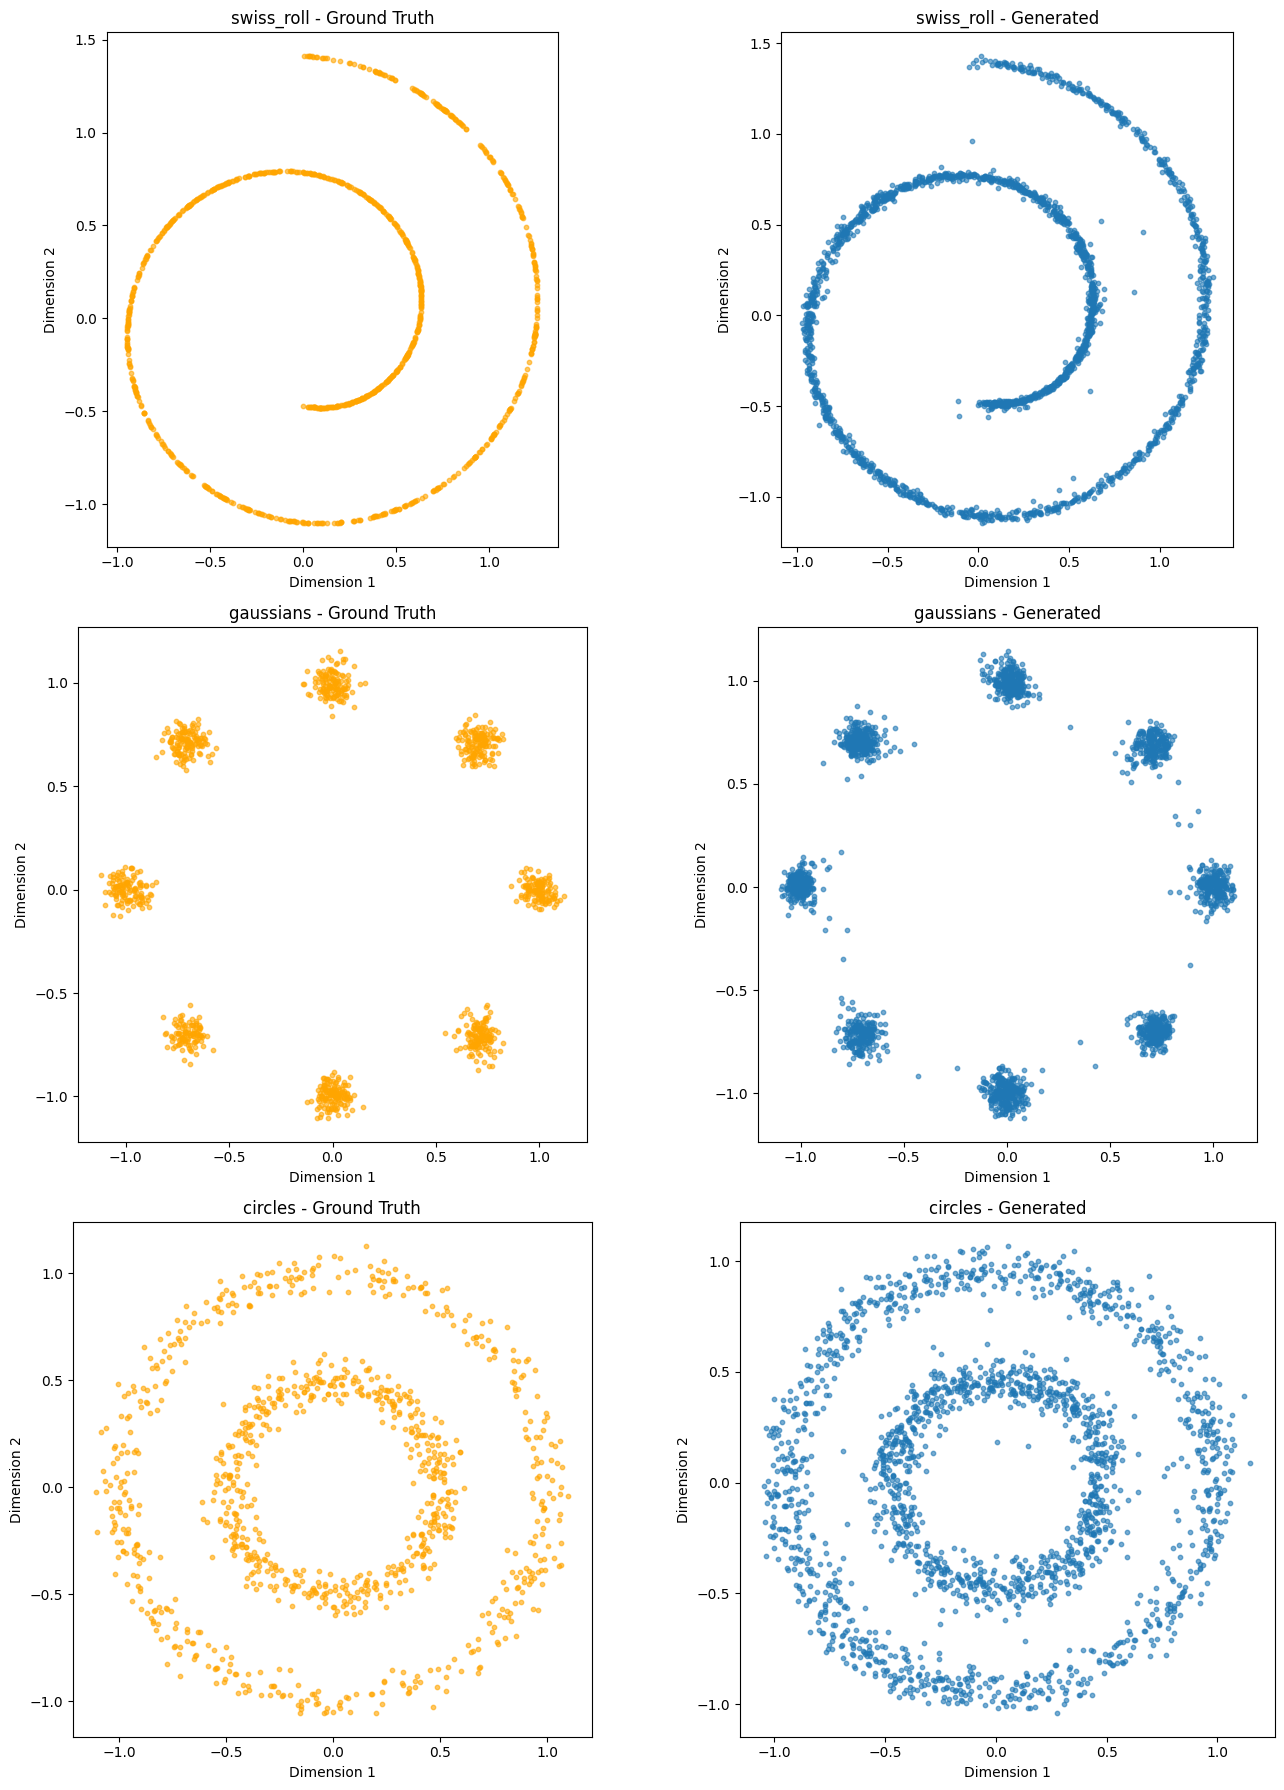

In [ ]:
n_datasets = len(results)
fig, axes = plt.subplots(n_datasets, 2, figsize=(14, 6 * n_datasets))

if n_datasets == 1:
    axes = axes[None, :]

for i, (name, data) in enumerate(results.items()):
    truth = data["truth"]
    gen = data["generated"]

    axes[i, 0].scatter(truth[:, 0], truth[:, 1],
                       alpha=0.6, s=10, c="orange")
    axes[i, 0].set_title(f"{name} - Ground Truth")
    axes[i, 0].set_xlabel("Dimension 1")
    axes[i, 0].set_ylabel("Dimension 2")
    axes[i, 0].set_aspect("equal")

    axes[i, 1].scatter(gen[:, 0], gen[:, 1],
                       alpha=0.6, s=10, c="C0")
    axes[i, 1].set_title(f"{name} - Generated")
    axes[i, 1].set_xlabel("Dimension 1")
    axes[i, 1].set_ylabel("Dimension 2")
    axes[i, 1].set_aspect("equal")

fig.tight_layout()
fig.savefig(OUT_DIR / "JiM_grid.png", dpi=150, bbox_inches="tight")
print(f"saved -> {OUT_DIR / 'JiM_grid.png'}")
plt.show()
plt.close(fig)